# 06 — PIXELAV sensor response: from track crossings to pixel charge clusters

Notebook 05 turned the shower into **per-sensor track crossings** — for each charged track that
crosses a 320 µm silicon sensor, its entry point, direction and (now real) momentum. This notebook
runs **PIXELAV** (M. Swartz's silicon charge-transport Monte Carlo) on those crossings and studies
the output: the **pixel charge cluster** a real DECAL readout would record, and the observables
reconstructed from it.

**What PIXELAV actually does**, per crossing:
1. **Ionisation** — lays down electron–hole pairs along the track through the 320 µm of silicon,
   using Bichsel's dE/dx cross-sections (Landau/Vavilov fluctuations + delta rays), *not* Geant4's
   deposited energy. It generates its own ionisation from the track's geometry and momentum.
2. **Transport** — drifts the electrons and holes through the sensor's electric field (and
   magnetic field, here zero), with diffusion and trapping, to the collecting pixels.
3. **Induction** — converts the moving charge into the **induced signal on each pixel** via the
   Ramo weighting potential, shaped by a CR-RC preamp into 20 time slices.

The result, per crossing, is a **13 × 21 grid of pixel charges** (rows = the 13-pixel *y* axis,
columns = the 21-pixel *x* axis; the track always crosses near the centre pixel). That grid is the
*cluster*. The sections below characterise the cluster and its dependence on the track.

Two upgrades since the first pass (both validated here): the deck now carries the **real
per-crossing momentum** (nb05 §5), and electrons/positrons are fed to PIXELAV's pion-dE/dx at the
**βγ-matched momentum** (`ppion = p·m_π/m`) so a soft shower electron ionises like the relativistic
particle it is, not like a slow pion. Build/run recipe: [`setup/setup_pixelav.sh`](../setup/setup_pixelav.sh)
and [`docs/pixelav_journey_log.md`](../docs/pixelav_journey_log.md).

In [1]:
import os, numpy as np, matplotlib.pyplot as plt
from matplotlib.patches import Rectangle
from matplotlib.colors import LogNorm
plt.rcParams['figure.dpi'] = 115

TY, TX = 13, 21                 # cluster grid: 13 rows (y), 21 cols (x)
CROW, CCOL = 6, 10              # centre pixel pix_06_10
PITCH = 100.0                   # um, square DECAL pixel
THICK = 320.0                   # um, Si thickness
EH_eV = 3.68                    # eV per e-h pair in Si (for the charge<->energy cross-check)

def parse(path, want_slices=False):
    """Return [(header, total_grid[, slices])]. total_grid is the 13x21 charge summed over the\n
    20 CR-RC time slices, x10 (the PIXELAV sampling factor) -> e-h pairs. header = the 9 floats\n
    [x-entry y-entry z-entry px py pz neh y_module pT] (lengths um, momenta GeV)."""
    out, hdr, slices, cur = [], None, [], []
    def flush():
        if hdr is None: return
        sl = np.array(slices) if slices else np.zeros((0, TY, TX))
        g = sl.sum(0) if sl.size else np.zeros((TY, TX))    # time-integrated spatial SHAPE (CR-RC waveform)
        neh = hdr[6] if hdr else 0.0                          # true e-h count for this crossing (header field 7)
        if g.sum() > 0: g = g / g.sum() * neh                 # normalize the shape to the true charge -> g.sum()=neh
        out.append((hdr, g, sl) if want_slices else (hdr, g))
    for line in open(path):
        s = line.strip()
        if s.startswith('<cluster>'):
            if cur: slices.append(cur)          # capture the final (20th) time slice of the previous cluster
            flush(); hdr, slices, cur = None, [], []
        elif s.startswith('<time slice'):
            if cur: slices.append(cur); cur = []
        elif s.startswith('<') or not s:
            continue
        else:
            p = s.split()
            if hdr is None and len(p) == 9: hdr = [float(x) for x in p]
            elif len(p) == TX: cur.append([float(x) for x in p])
    if cur: slices.append(cur)
    flush()
    return out

M = '../models/'
EX   = parse(M+'pixelav_clusters_examples.out', want_slices=True)
AX   = parse(M+'pixelav_clusters_axis.out')
FULL = parse(M+'pixelav_clusters_full.out')
print(f'{len(EX)} example clusters, {len(AX)} axis clusters, {len(FULL)} full-event clusters')

6 example clusters, 2 axis clusters, 1042 full-event clusters


## 1. What a single cluster *is* — read one carefully

Below is **one** crossing's cluster: a perpendicular-ish track. The image is the 13 × 21 grid of
pixels; colour is the charge (e-h pairs) collected on each pixel. The **★** marks where the track
actually crossed (its entry point, from the truth deck), and the **arrow** shows the track's
in-plane direction. The white lines mark the centre pixel.

Key features of the cluster, and why:
- The charge is concentrated in **one or a few pixels** around the impact. A perpendicular track
  in 320 µm of silicon deposits a thin line of charge straight down; that charge drifts to the
  collecting plane and lands mostly under the pixel it crossed, with a little **sharing** into
  neighbours from diffusion during the drift.
- The grid is *not* the whole sensor — it is a small **patch of 21 × 13 pixels around the impact**.
  PIXELAV only simulates the pixels that can catch charge; where on the full wedge the track landed
  is irrelevant to the cluster shape (only the sub-pixel impact and the angle matter).
- Total charge here is ~a MIP for 320 µm silicon (~25 k e-h). That sets the energy scale; the
  *shape* is what carries position and angle information.

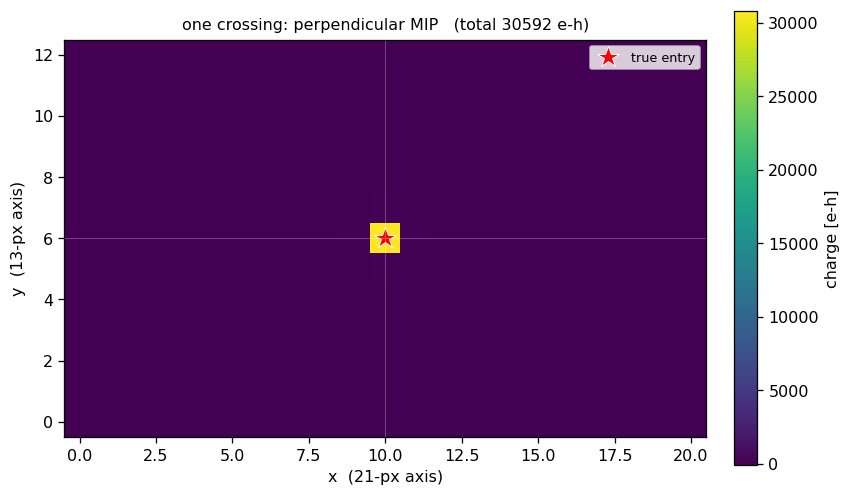

In [2]:
def show_cluster(ax, hdr, g, title):
    im = ax.imshow(g, origin='lower', cmap='viridis', aspect='equal')
    # entry point (um, relative to centre pixel) -> pixel coords
    xcol = CCOL + hdr[0]/PITCH; yrow = CROW + hdr[1]/PITCH
    ax.plot(xcol, yrow, 'r*', ms=14, mec='w', mew=0.6, label='true entry')
    px, py, pz = hdr[3], hdr[4], hdr[5]
    if abs(pz) > 1e-9:                       # in-plane direction over the full depth, in pixels
        dx = (THICK*px/pz)/PITCH; dy = (THICK*py/pz)/PITCH
        n = np.hypot(dx, dy)
        if n > 0.05:
            ax.annotate('', xy=(xcol+dx, yrow+dy), xytext=(xcol, yrow),
                        arrowprops=dict(arrowstyle='->', color='w', lw=1.6))
    ax.axhline(CROW, color='w', lw=0.4, alpha=0.4); ax.axvline(CCOL, color='w', lw=0.4, alpha=0.4)
    ax.set_xlabel('x  (21-px axis)'); ax.set_ylabel('y  (13-px axis)'); ax.set_title(title, fontsize=10)
    return im

# pick a clean near-perpendicular example (the first gallery entry)
hdr, g = EX[0][0], EX[0][1]
fig, ax = plt.subplots(figsize=(7.5, 4.6))
im = show_cluster(ax, hdr, g, f'one crossing: perpendicular MIP   (total {g.sum():.0f} e-h)')
ax.legend(loc='upper right', fontsize=8); fig.colorbar(im, ax=ax, fraction=0.046, pad=0.04, label='charge [e-h]')
plt.tight_layout(); plt.show()

## 2. How the cluster changes with the track — the gallery, explained

The cluster *shape* encodes the track. Each panel below is a different track through the **same**
sensor; the ★ and arrow are the truth entry and direction as before. Panel by panel:

- **perpendicular MIP** — a tight blob: the track goes straight down, so all the charge lands under
  the entry pixel (± a little diffusion sharing).
- **inclined in u / in v** — the cluster **stretches** along the direction the track is tilted: as
  the track descends through 320 µm it walks sideways across pixels, so the charge is laid down
  along a line. (Which image axis it stretches along is the cot↔axis convention of §3.)
- **diagonal** — tilted in both directions → stretched diagonally.
- **offset entry** — same perpendicular track but entering 40 µm off-centre: the blob shifts and
  shares differently between pixels. This sub-pixel position is exactly what sets a hit's measured
  position (§5); the real-entry driver feeds this sub-pixel position to PIXELAV instead of the
  default randomised impact (nb05 §4).
- **slow track (low βγ)** — a genuinely slow particle sits on the Bethe **1/β² rise** and ionises
  *more* per unit length, so its cluster is brighter. Our real shower electrons are the opposite —
  low in momentum but **ultra-relativistic**, so the βγ-match feeds them as high-βγ pions and they
  deposit a MIP. The contrast with the relativistic shower electrons is why the βγ-rescaling matters.

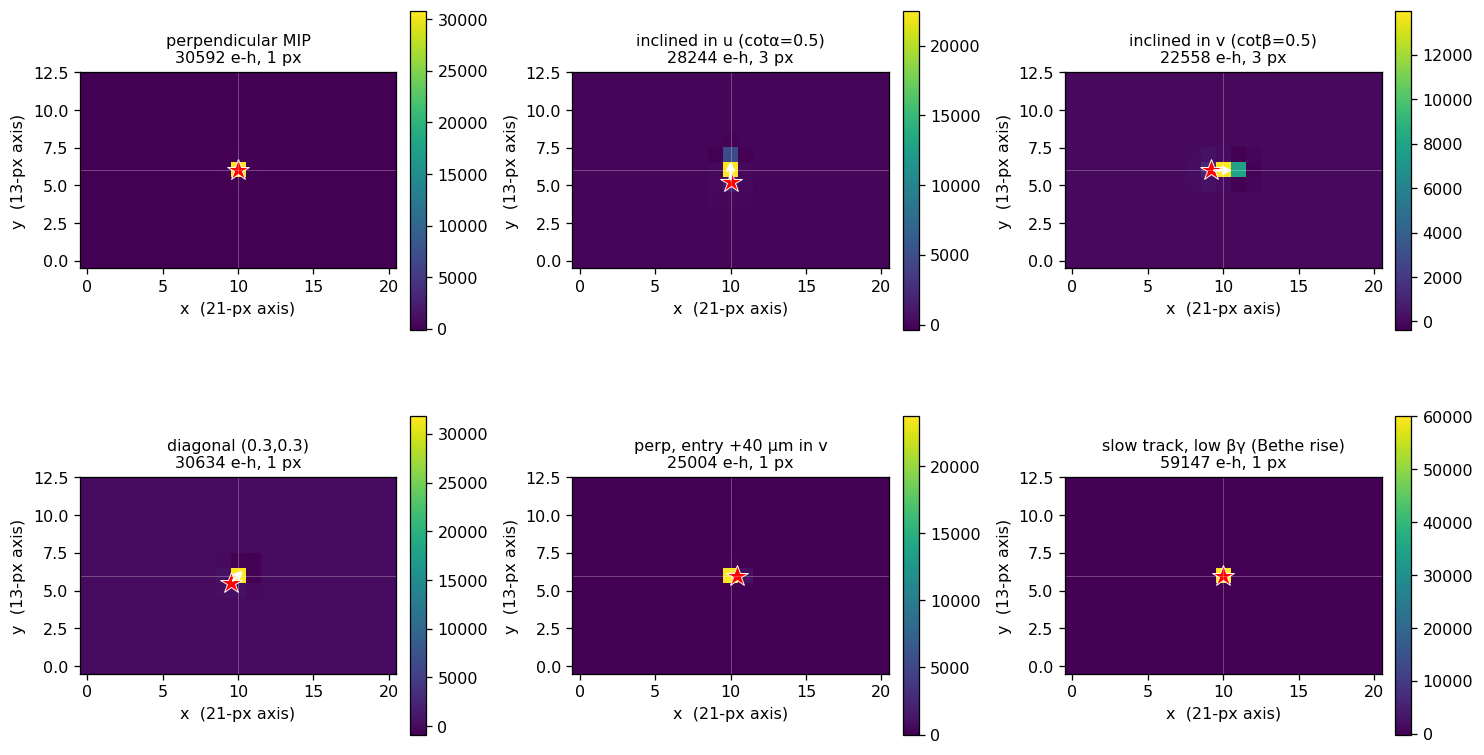

In [3]:
titles = ['perpendicular MIP', 'inclined in u (cotα=0.5)', 'inclined in v (cotβ=0.5)',
          'diagonal (0.3,0.3)', 'perp, entry +40 µm in v', 'slow track, low βγ (Bethe rise)']
fig, axes = plt.subplots(2, 3, figsize=(13, 7.2))
for ax, (hdr, g, sl), t in zip(axes.flat, EX, titles):
    im = show_cluster(ax, hdr, g, f'{t}\n{g.sum():.0f} e-h, {int((g>0.05*g.max()).sum())} px')
    fig.colorbar(im, ax=ax, fraction=0.046, pad=0.04)
plt.tight_layout(); plt.show()

## 3. The cot ↔ axis convention (why we verified it)

PIXELAV's driver labels the two track slopes `cot_alpha` and `cot_beta`, and — as its source shows —
swaps them relative to the CMS text. So the mapping has to be read off the code and **checked against
the binary**: `cot_alpha` tilts the track along the **13-px (y) axis**, `cot_beta` along the **21-px
(x) axis**. Combined with the DECAL local frame this means the deck writes `cot_alpha = p_u/p_w`
(across-pitch slope) and `cot_beta = p_v/p_w` (cylinder-z slope). Getting it wrong would rotate every
cluster by 90°. The two single-axis tracks below confirm it: tilt only in `cot_alpha` and the cluster
elongates **vertically** (13-px y); tilt only in `cot_beta` and it elongates **horizontally** (21-px x).

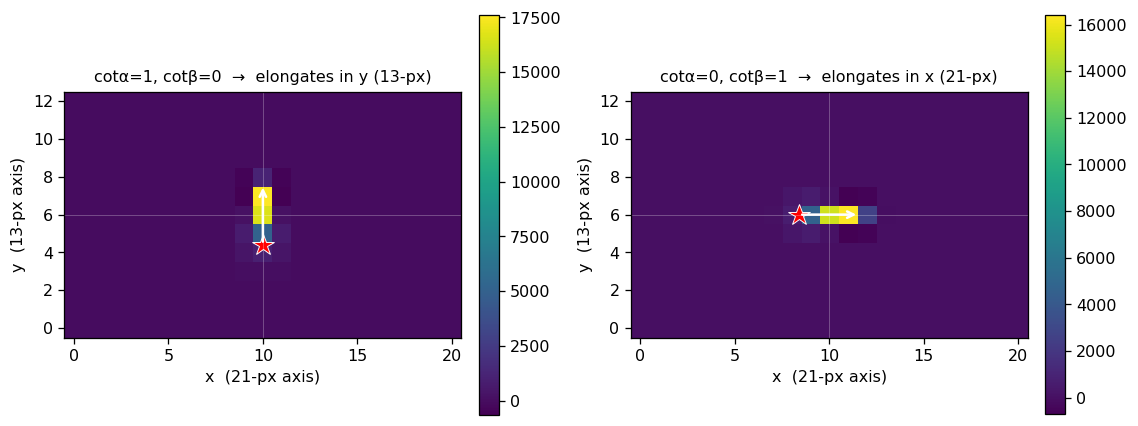

In [4]:
fig, axes = plt.subplots(1, 2, figsize=(10, 4.3))
lab = ['cotα=1, cotβ=0  →  elongates in y (13-px)', 'cotα=0, cotβ=1  →  elongates in x (21-px)']
for ax, (hdr, g), t in zip(axes, AX, lab):
    im = show_cluster(ax, hdr, g, t)
    fig.colorbar(im, ax=ax, fraction=0.046, pad=0.04)
plt.tight_layout(); plt.show()

## 4. Peeking inside PIXELAV — the transport physics

Two looks under the hood. **Left:** PIXELAV reports the signal in **20 CR-RC time slices**, so we
can watch the induced charge build up as the carriers drift to the collecting plane — the cluster
is not instantaneous, it develops over the drift/shaping time (the basis of any timing measurement).
**Right:** across the full event, the cluster's collected charge grows with the track's inclination
`|cot|`: a tilted track has a longer path in the 320 µm sensor, so it ionises more — the expected
`1/cos θ` path-length effect.

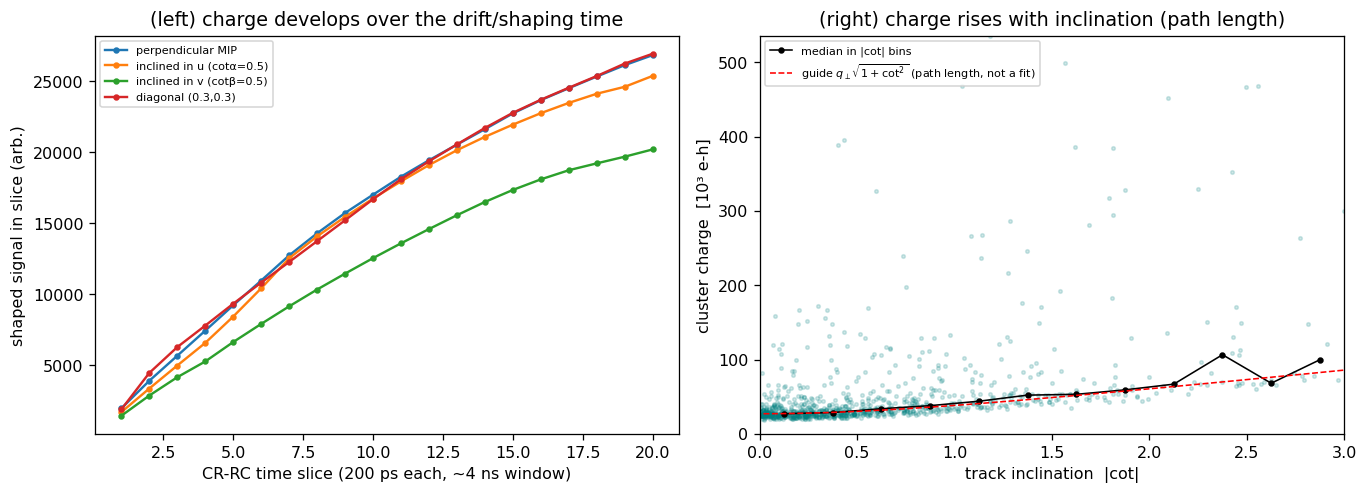

In [5]:
fig, (a0, a1) = plt.subplots(1, 2, figsize=(12, 4.4))
# (left) time development: per-slice total charge for a few example crossings
for (hdr, g, sl), t in zip(EX[:4], titles):
    if sl.size:
        a0.plot(np.arange(1, sl.shape[0]+1), sl.reshape(sl.shape[0], -1).sum(1), '-o', ms=3, label=t)
a0.set_xlabel('CR-RC time slice (200 ps each, ~4 ns window)'); a0.set_ylabel('shaped signal in slice (arb.)')
a0.set_title('(left) charge develops over the drift/shaping time'); a0.legend(fontsize=7)
# (right) cluster charge vs inclination, full event
Q   = np.array([g.sum() for _, g in FULL])
cot = np.array([np.hypot(h[3]/h[5], h[4]/h[5]) if abs(h[5])>1e-9 else np.nan for h, _ in FULL])
good = np.isfinite(cot) & (cot < 5) & (Q > 0)
a1.scatter(cot[good], Q[good]/1e3, s=5, alpha=0.18, color='teal')
cb = np.linspace(0, 3, 13); ci = np.digitize(cot[good], cb)
med = [np.median(Q[good][ci==k])/1e3 if np.any(ci==k) else np.nan for k in range(1, len(cb))]
a1.plot(0.5*(cb[1:]+cb[:-1]), med, 'ko-', ms=3, lw=1, label='median in |cot| bins')
q0 = np.median(Q[good][cot[good] < 0.1])/1e3 if np.any(cot[good] < 0.1) else 25.0
xg = np.linspace(0.02, 3, 100); a1.plot(xg, q0*np.sqrt(1+xg**2), 'r--', lw=1, label=r'guide $q_\perp\sqrt{1+\cot^2}$ (path length, not a fit)')
a1.set_xlabel('track inclination  |cot|'); a1.set_ylabel('cluster charge  [10³ e-h]')
a1.set_title('(right) charge rises with inclination (path length)'); a1.legend(fontsize=7); a1.set_xlim(0, 3); a1.set_ylim(0, np.percentile(Q[good],98)/1e3*1.2)
plt.tight_layout(); plt.show()

## 5. Downstream observables — what a real readout measures

A real readout never sees the truth track, only the cluster. From it one reconstructs:
- **collected charge** (a dE/dx / energy estimator),
- **cluster size** (how many pixels fired — an angle/position handle),
- **hit position** — the charge-weighted centroid of the cluster.

Each is shown against its physics expectation. The **charge** spectrum should be **Landau-shaped** —
thin-silicon energy loss with a most-probable value at the ~85 keV → 23.1k e-h MIP for 320 µm Si and a
long high-side delta-ray tail (so the mean/median sit above the MPV). **Cluster size** should peak at
1–2 pixels (a perpendicular MIP deposits under one pixel, plus a little diffusion sharing) with a tail
to larger sizes from inclined tracks walking across pixels. §5b then tests these against the track
kinematics directly.

The third is the headline for an imaging calorimeter. Below: the charge spectrum and cluster size
over the full event, then the **position residual** — the charge-weighted centroid minus the true
sub-pixel entry PIXELAV was given. Two caveats make this a *proxy*, not the final resolution: the
centroid is the simplest estimator (biased toward pixel centres — the classic charge-sharing 'eta'
effect; a PIXELAV *template* fit does better), and for an **inclined** track the centroid tracks the
mid-plane, offset from the entry face by ~(t/2)·cot ≈ 160 µm·cot, which would dominate the width. So
we quote the residual on **near-perpendicular** crossings (|cot| < 0.1), where it reflects the
intrinsic resolution: even the bare centroid already beats the binary (hit/no-hit) floor of
pitch/√12 ≈ 29 µm, thanks to charge sharing — and a template fit would do better still.

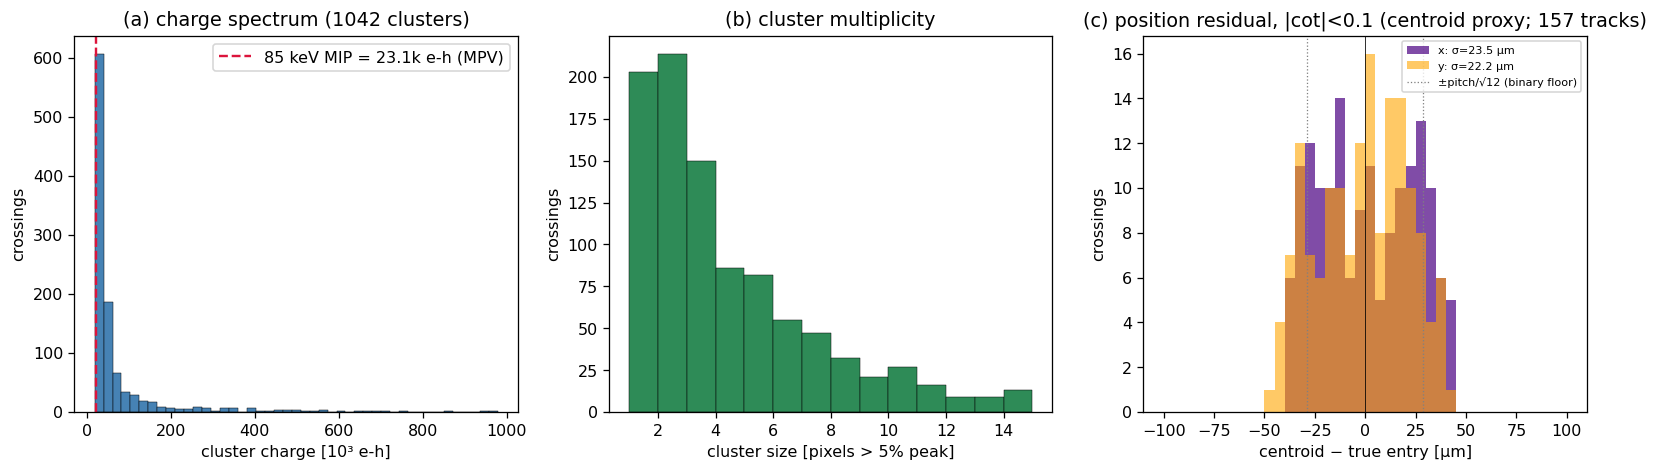

binary floor pitch/√12 = 28.9 µm;  near-perpendicular centroid σ_x=23.5 µm, σ_y=22.2 µm  (157 tracks)
median cluster charge = 34709 e-h  ≈  128 keV  — consistent with the ~85 keV MIP in 320 µm Si (PIXELAV sets this from its own Bichsel ionisation, independent of Geant4)
(Σ over the 1042 clusters here = 0.277 GeV; the full event deposits ≈0.53 GeV in Si — a total comparison needs all crossings and excludes |cot|>10 grazing)


In [6]:
Q     = np.array([g.sum() for _, g in FULL])
size  = np.array([int((g > 0.05*g.max()).sum()) for _, g in FULL if g.max() > 0])
# charge-weighted centroid residual (reconstructed - true entry), um, for clusters with charge
resx, resy, cotc = [], [], []
ys, xs = np.indices((TY, TX))
for hdr, g in FULL:
    tot = g.sum()
    if tot <= 0: continue
    cx = (g*xs).sum()/tot; cy = (g*ys).sum()/tot
    resx.append((cx - CCOL)*PITCH - hdr[0]); resy.append((cy - CROW)*PITCH - hdr[1])
    cotc.append(np.hypot(hdr[3]/hdr[5], hdr[4]/hdr[5]) if abs(hdr[5]) > 1e-9 else 99.0)
resx, resy, cotc = np.array(resx), np.array(resy), np.array(cotc)
perp = (cotc < 0.1) & (np.abs(resx) < PITCH) & (np.abs(resy) < PITCH)   # near-perpendicular, well-contained

fig, ax = plt.subplots(1, 3, figsize=(14, 4.2))
ax[0].hist(Q/1e3, bins=45, color='steelblue', edgecolor='k', lw=0.3)
ax[0].axvline(23.1, color='crimson', ls='--', label='85 keV MIP = 23.1k e-h (MPV)'); ax[0].legend()
ax[0].set_xlabel('cluster charge [10³ e-h]'); ax[0].set_ylabel('crossings'); ax[0].set_title(f'(a) charge spectrum ({len(FULL)} clusters)')
ax[1].hist(size, bins=range(1, 16), color='seagreen', edgecolor='k', lw=0.3)
ax[1].set_xlabel('cluster size [pixels > 5% peak]'); ax[1].set_ylabel('crossings'); ax[1].set_title('(b) cluster multiplicity')
ax[2].hist(resx[perp], bins=40, range=(-PITCH, PITCH), color='indigo', alpha=0.7, label=f'x: σ={resx[perp].std():.1f} µm')
ax[2].hist(resy[perp], bins=40, range=(-PITCH, PITCH), color='orange', alpha=0.6, label=f'y: σ={resy[perp].std():.1f} µm')
ax[2].axvline(0, color='k', lw=0.5); ax[2].axvline(PITCH/np.sqrt(12), color='gray', ls=':', lw=0.8); ax[2].axvline(-PITCH/np.sqrt(12), color='gray', ls=':', lw=0.8, label='±pitch/√12 (binary floor)')
ax[2].set_xlabel('centroid − true entry [µm]'); ax[2].set_ylabel('crossings')
ax[2].set_title(f'(c) position residual, |cot|<0.1 (centroid proxy; {int(perp.sum())} tracks)'); ax[2].legend(fontsize=7)
plt.tight_layout(); plt.show()
print(f'binary floor pitch/√12 = {PITCH/np.sqrt(12):.1f} µm;  near-perpendicular centroid σ_x={resx[perp].std():.1f} µm, σ_y={resy[perp].std():.1f} µm  ({int(perp.sum())} tracks)')
print(f'median cluster charge = {np.median(Q):.0f} e-h  ≈  {np.median(Q)*EH_eV/1e3:.0f} keV  — consistent with the ~85 keV MIP in 320 µm Si (PIXELAV sets this from its own Bichsel ionisation, independent of Geant4)')
print(f'(Σ over the {len(FULL)} clusters here = {Q.sum()*EH_eV/1e9:.3f} GeV; the full event deposits ≈0.53 GeV in Si — a total comparison needs all crossings and excludes |cot|>10 grazing)')

## 5b. The observables against their physics expectations

Three direct tests that the cluster observables behave as the physics demands:
- **(a) cluster size vs inclination** — a tilted track traverses a longer path in the 320 µm sensor,
  so it should light up about `1 + (t/pitch)·|cot| = 1 + 3.2·|cot|` pixels; the points should follow
  that geometric line.
- **(b) cluster charge vs βγ** — PIXELAV is fed every track at its βγ-matched momentum, so the shower
  electrons sit on the **Fermi plateau** (βγ ≫ the βγ≈3 MIP minimum) at ~1 MIP, *not* on the low-βγ
  1/β² rise. This is the event-level payoff of the βγ-rescaling argued in nb05 §5 and §2 above.
- **(c) the η non-linearity** — the charge-weighted centroid vs the true sub-pixel entry (near-
  perpendicular tracks). A perfect estimator lies on the dashed `y=x`; the real centroid is pulled
  toward pixel centres into the classic **η S-curve** — exactly why the §5(c) residual is a *proxy*
  and a template fit (the next step) does better.

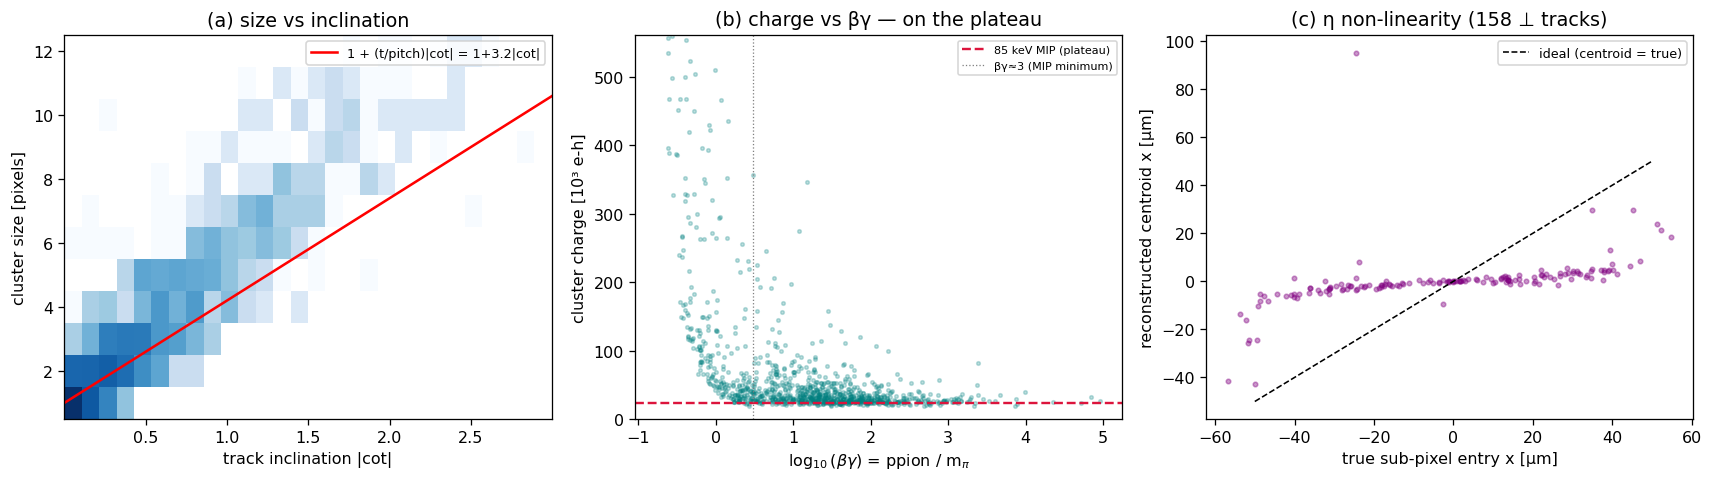

In [7]:
Qn    = np.array([h[6] for h, _ in FULL])                       # cluster charge (e-h)
cotF  = np.array([np.hypot(h[3]/h[5], h[4]/h[5]) if abs(h[5]) > 1e-9 else np.nan for h, _ in FULL])
sizeF = np.array([int((g > 0.05*g.max()).sum()) if g.max() > 0 else 0 for _, g in FULL])
bg    = np.array([np.hypot(np.hypot(h[3], h[4]), h[5]) / 0.13957 for h, _ in FULL])  # ppion -> betagamma
ys, xs = np.indices((TY, TX))
fig, ax = plt.subplots(1, 3, figsize=(15, 4.3))
gd = np.isfinite(cotF) & (cotF < 3) & (sizeF > 0)
ax[0].hist2d(cotF[gd], sizeF[gd], bins=[28, np.arange(0.5, 13)], cmap='Blues', norm=LogNorm())
xc = np.linspace(0, 3, 50); ax[0].plot(xc, 1 + (THICK/PITCH)*xc, 'r-', lw=1.6, label=f'1 + (t/pitch)|cot| = 1+{THICK/PITCH:.1f}|cot|')
ax[0].set_xlabel('track inclination |cot|'); ax[0].set_ylabel('cluster size [pixels]'); ax[0].set_title('(a) size vs inclination'); ax[0].legend(fontsize=8)
gd2 = (Qn > 0) & (bg > 0)
ax[1].scatter(np.log10(bg[gd2]), Qn[gd2]/1e3, s=5, alpha=0.25, color='teal')
ax[1].axhline(23.1, color='crimson', ls='--', label='85 keV MIP (plateau)'); ax[1].axvline(np.log10(3), color='gray', ls=':', lw=0.8, label='βγ≈3 (MIP minimum)')
ax[1].set_xlabel(r'$\log_{10}(\beta\gamma)$ = ppion / m$_\pi$'); ax[1].set_ylabel('cluster charge [10³ e-h]'); ax[1].set_title('(b) charge vs βγ — on the plateau'); ax[1].legend(fontsize=7); ax[1].set_ylim(0, np.percentile(Qn[gd2], 98)/1e3*1.2)
truex, recx = [], []
for h, g in FULL:
    if g.sum() <= 0: continue
    if abs(h[5]) > 1e-9 and np.hypot(h[3]/h[5], h[4]/h[5]) > 0.1: continue
    cx = (g*xs).sum()/g.sum(); truex.append(h[0]); recx.append((cx - CCOL)*PITCH)
truex, recx = np.array(truex), np.array(recx)
ax[2].scatter(truex, recx, s=8, alpha=0.4, color='purple')
ax[2].plot([-PITCH/2, PITCH/2], [-PITCH/2, PITCH/2], 'k--', lw=1, label='ideal (centroid = true)')
ax[2].set_xlabel('true sub-pixel entry x [µm]'); ax[2].set_ylabel('reconstructed centroid x [µm]'); ax[2].set_title(f'(c) η non-linearity ({len(truex)} ⊥ tracks)'); ax[2].legend(fontsize=8)
plt.tight_layout(); plt.show()

## 6. The DECAL sensor model (Stage-A) — what we assume and why it is reasonable

PIXELAV needs a sensor model: the electric field, the Ramo weighting potential, thickness, pitch,
bias, temperature and B-field. With no TCAD field map yet, we use a deliberately simple but
**self-consistent and well-justified** model (`analysis/pixelav/make_decal_stagea.py`):

| Assumption | Value | Why it is appropriate here |
|---|---|---|
| thickness / pitch | 320 µm / 100 µm | **exact**, from `geometry/my_custom_ecal.xml` |
| magnetic field | **B = 0** | **matches the sim** — the test-beam `<fields>` block sets the solenoid to 0 T, so there is no Lorentz drift in either the shower or the sensor |
| electric field | uniform `E_z = −10⁴ V/cm` (≈ 320 V bias) | an over-depleted planar sensor; at ~1 V/µm the carriers are near **velocity saturation**, so cluster shapes are insensitive to the exact field profile — the main thing a TCAD map would refine |
| weighting potential | exact 3-D **Ramo** solution (FFT) | geometry-correct for our pitch/thickness; rises 0→1 from backplane to collection |
| temperature / rad-damage | 300 K / none | room-temperature, unirradiated test-beam operation |

The two panels below show the model along the sensor depth: the (uniform) drift field, and the
central-pixel Ramo weighting potential rising to 1 at the collecting electrode (charge induces
signal mostly as it nears the pixel — the small-pixel/near-electrode behaviour).

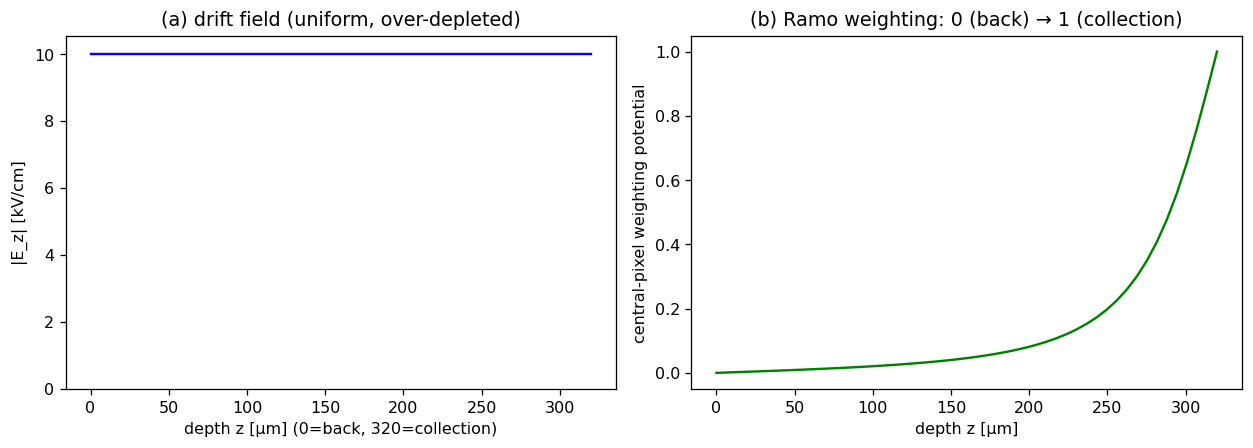

In [8]:
def read_init_axis(path, ncols):
    """Read a ppixel2/wgt_pot .init grid and return the central-axis (ix=iy=0) profile vs node iz."""
    rows = []
    with open(path) as f:
        for line in f:
            p = line.split()
            if len(p) >= 3+ncols and p[0].lstrip('-').isdigit() and p[1].isdigit() and p[2].isdigit():
                if int(p[0]) == 1 and int(p[1]) == 1:
                    rows.append((int(p[2]), [float(x) for x in p[3:3+ncols]]))
    rows.sort()
    return np.array([r[0] for r in rows]), np.array([r[1] for r in rows])

RUN = None
for c in ['/tmp/pixelav_journey/pixelav/decal_run', M]:
    if os.path.exists(os.path.join(c, 'ppixel2.decal.init')): RUN = c; break
fig, (a0, a1) = plt.subplots(1, 2, figsize=(11, 4))
if RUN:
    iz, ef = read_init_axis(os.path.join(RUN,'ppixel2.decal.init'), 3)   # Ex Ey Ez (V/cm)
    z = (iz-1)/(iz.max()-1)*THICK
    a0.plot(z, -ef[:,2]/1e3, 'b-'); a0.set_xlabel('depth z [µm] (0=back, 320=collection)')
    a0.set_ylabel('|E_z| [kV/cm]'); a0.set_title('(a) drift field (uniform, over-depleted)'); a0.set_ylim(0, None)
    izw, w = read_init_axis(os.path.join(RUN,'wgt_pot.decal.init'), 9)   # 3x3; W[1][1]=col index 4
    zw = (izw-1)/(izw.max()-1)*THICK
    a1.plot(zw, w[:,4], 'g-'); a1.set_xlabel('depth z [µm]'); a1.set_ylabel('central-pixel weighting potential')
    a1.set_title('(b) Ramo weighting: 0 (back) → 1 (collection)')
else:
    a0.text(0.5,0.5,'run setup_pixelav.sh to generate the Stage-A files', ha='center'); a1.axis('off')
plt.tight_layout(); plt.show()

## 7. Summary

- A PIXELAV **cluster** is the 13×21 grid of induced pixel charge for one track crossing the 320 µm
  DECAL sensor — ionisation (Bichsel) → drift/diffusion → Ramo induction, in 20 time slices.
- The cluster **shape** encodes the track: compact for perpendicular MIPs, elongated along the tilt
  for inclined tracks (cot_alpha→13-px y, cot_beta→21-px x, verified against the binary), shifted by
  the sub-pixel entry, brighter/fuzzier for soft electrons.
- The **downstream observables** are the collected charge (peaks at the 320 µm MIP), the cluster
  size, and — the headline — the charge-weighted position, whose residual to truth gives an
  **indicative single-hit resolution** (a centroid proxy on this event's near-perpendicular tracks,
  already inside the pitch/√12 binary floor; the η curve in §5b shows why a template fit would do
  better).
- **What is real:** the per-crossing kinematics (entry, direction, momentum, type) come from the
  DECAL Geant4 cascade; electrons are fed at the βγ-matched momentum so their dE/dx is physical.
- **What is simple (documented §6):** a uniform drift field + analytic Ramo weighting + B=0, all
  appropriate for this field-free, over-depleted, unirradiated sensor; a TCAD field map would refine
  the cluster shapes (not the charge scale). **What is next:** a TCAD field via `TCADtoPixelAV`, and
  building position-reconstruction *templates* from these clusters.